<a href="https://colab.research.google.com/github/sherinsafi/co2-emissions-analysis/blob/main/CO2_Emissions_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

## CO2 Emissions Analysis

# Domain
**Environment / Climate Science / Public Policy**

This project falls under the Environmental domain, specifically focusing on global greenhouse gas emissions — a topic critical to governments, energy companies, climate scientists, and policy makers worldwide.

# Objective

- To identify meaningful patterns, trends, and insights from global CO2 emissions data using Exploratory Data Analysis (EDA)
- To clean, transform, and preprocess the dataset for accurate analysis
- To create meaningful visualizations that clearly explain the story behind CO2 emissions across countries and time
- To provide actionable insights and recommendations for climate policy and decision-making

# Outcome

The project uncovers key patterns in global CO2 emissions — identifying which countries emit the most, how emissions have changed over time, which energy sources are responsible, and how economic growth relates to emissions. The analysis supports evidence-based climate policy decisions.


# Dataset Information

- **Source:** Our World in Data (OWID) — Open Data Portal
- **URL:** https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv
- **Year / Timeline:** Data spans from 1750 to present (analysis focuses on 1900–present)
- **Dataset Description:** Contains country-level and global CO2 and greenhouse gas emission data including total CO2, per capita CO2, CO2 by source (coal, oil, gas, cement, flaring), GDP, and population for every country across decades.


# Type of Analysis
- **Descriptive Analysis** — Summarizing global and country-level emissions trends
- **Diagnostic Analysis** — Finding reasons behind emission patterns (source breakdown, GDP correlation)
- **Prescriptive Analysis** — Recommendations for reducing emissions based on findings

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection



### Business Problem
Climate change is one of the most pressing global challenges. CO2 emissions from human activity are the primary driver. Decision-makers need to understand **who emits the most**, **which sectors are responsible**, and **how trends are changing** to design effective policies.

### Expected Outcome
- Identify top emitting countries (total and per capita)
- Track emission trends over time
- Understand which energy sources contribute most
- Understand how economic development relates to emissions

### Dataset Features (Key Columns)
| Column | Description |
|---|---|
| `country` | Country or region name |
| `year` | Year of observation |
| `co2` | Total CO2 emissions (million tonnes) |
| `co2_per_capita` | CO2 per person (tonnes) |
| `coal_co2` | CO2 from coal |
| `oil_co2` | CO2 from oil |
| `gas_co2` | CO2 from natural gas |
| `cement_co2` | CO2 from cement production |
| `gdp` | Gross Domestic Product (USD) |
| `population` | Country population |

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# Load the dataset directly from URL
URL = 'https://raw.githubusercontent.com/sherinsafi/co2-emissions-analysis/refs/heads/main/owid-co2-data.csv'
df = pd.read_csv(URL)

print('Dataset loaded successfully')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully
Shape: 50,411 rows × 79 columns


In [ ]:
# First look at the data (head)
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Dataset info (column types, non-null counts)
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  c

In [ ]:
# Descriptive statistics and shape
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

print('\n=== Descriptive Statistics (Key Columns) ===')
key_cols = ['year', 'co2', 'co2_per_capita', 'co2_per_gdp', 'coal_co2', 'oil_co2', 'gas_co2', 'population']
display(df[key_cols].describe().round(2))

=== Shape ===
Rows: 50,411   Columns: 79

=== Descriptive Statistics (Key Columns) ===


,year,co2,co2_per_capita,co2_per_gdp,coal_co2,oil_co2,gas_co2,population
count,50411.00,29384.00,26509.00,17528.00,21925.00,25459.00,18147.00,4.116700e+04
mean,1920.35,420.23,3.82,0.40,185.50,115.31,74.84,6.017453e+07
std,65.86,1972.09,14.31,0.75,855.42,646.56,397.30,3.308433e+08
min,1750.00,0.00,0.00,0.00,0.00,0.00,0.00,2.150000e+02
25%,1875.00,0.38,0.17,0.13,0.07,0.09,0.00,3.272140e+05
50%,1925.00,5.08,1.02,0.26,2.10,1.40,0.02,2.291594e+06
75%,1975.00,53.66,4.33,0.51,27.86,14.41,6.61,9.986553e+06
max,2024.00,38598.58,782.74,82.60,15805.25,12470.60,8009.83,8.161973e+09


In [ ]:
# Null check and Duplicate check
print('\n=== Null Values per Column ===')
null_df = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
display(null_df[null_df['Null Count'] > 0].sort_values('Null %', ascending=False).head(20))

print(f'\n=== Duplicate Rows ===')
print(f'Total duplicates: {df.duplicated().sum()}')


=== Null Values per Column ===


,Null Count,Null %
share_global_cumulative_other_co2,48241,95.70
share_global_other_co2,48241,95.70
other_co2_per_capita,47752,94.73
cumulative_other_co2,47157,93.55
other_industry_co2,47157,93.55
consumption_co2_per_gdp,45963,91.18
consumption_co2_per_capita,45768,90.79
trade_co2,45699,90.65
trade_co2_share,45699,90.65
consumption_co2,45358,89.98



=== Duplicate Rows ===
Total duplicates: 0


## Stage 2 – Data Cleaning and Pre-processing


In [ ]:
#  Separate Countries from Non-Country Aggregates

# The OWID dataset mixes individual country rows WITH continental/global
# aggregates (e.g. 'World', 'Asia', 'Europe', 'High-income countries').
# If we keep aggregates alongside countries, every emission is DOUBLE-COUNTED
# once in the country row, and again in the regional total row.
# We must separate them BEFORE any analysis or cleaning.

# IDENTIFYING NON-COUNTRIES:
# - Rows with iso_code = NaN  → no ISO code means it's a regional group
# - Rows with iso_code starting 'OWID_' -> Our World in Data custom aggregates

non_country_mask = df['iso_code'].isna() | df['iso_code'].str.startswith('OWID_', na=False)

# Store world aggregate separately — needed for global trend charts
df_world    = df[df['country'] == 'World'].copy()

# Main working dataset: country-level rows only (no double-counting)
df_countries = df[~non_country_mask].copy()

print('Non-country entities removed from main dataset:')
print(df[non_country_mask]['country'].unique())
print(f'\nMain dataset (countries only) : {len(df_countries):,} rows')
print(f'World aggregate rows (kept)   : {len(df_world):,} rows')

Non-country entities removed from main dataset:
['Africa' 'Africa (GCP)' 'Asia' 'Asia (GCP)'
 'Asia (excl. China and India)' 'Central America (GCP)' 'Europe'
 'Europe (GCP)' 'Europe (excl. EU-27)' 'Europe (excl. EU-28)'
 'European Union (27)' 'European Union (28)' 'High-income countries'
 'International aviation' 'International shipping' 'Kosovo'
 'Kuwaiti Oil Fires' 'Kuwaiti Oil Fires (GCP)'
 'Least developed countries (Jones et al.)' 'Low-income countries'
 'Lower-middle-income countries' 'Middle East (GCP)' 'Non-OECD (GCP)'
 'North America' 'North America (GCP)' 'North America (excl. USA)'
 'OECD (GCP)' 'OECD (Jones et al.)' 'Oceania' 'Oceania (GCP)'
 'Ryukyu Islands' 'Ryukyu Islands (GCP)' 'South America'
 'South America (GCP)' 'Upper-middle-income countries' 'World']

Main dataset (countries only) : 42,480 rows
World aggregate rows (kept)   : 275 rows


In [ ]:
# Filter to modern era (1900 onward) for more complete and relevant data

# Data before 1900 is extremely sparse - most countries have no recorded
# emissions for the majority of columns (coal, oil, gas, population, GDP).
# Including pre-1900 data would:
#   1. Inflate missing-value counts dramatically (making cleaning harder)
#   2. Skew descriptive statistics toward near-zero or NaN values
#   3. Produce misleading visualizations with large empty gaps
# The analysis focuses on the industrial era (1900–present) where data
# quality and completeness is significantly better.

df_modern  = df_countries[df_countries['year'] >= 1900].copy()
df_world_m = df_world[df_world['year'] >= 1900].copy()

print(f'After filtering to 1900+:')
print(f'  Country-level rows : {len(df_modern):,}')
print(f'  World rows         : {len(df_world_m)}')
print(f'  Year range         : {df_modern["year"].min()} – {df_modern["year"].max()}')

After filtering to 1900+:
  Country-level rows : 27,250
  World rows         : 125
  Year range         : 1900 – 2024


In [ ]:
# Handle missing values
# Before deciding HOW to handle missing data, we need to understand
# WHICH columns are affected and HOW MUCH.

missing_count = df_modern.isnull().sum()
missing_pct   = (missing_count / len(df_modern) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df    = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {df_modern.shape[1]}')
print(missing_df.head(15).to_string())

Columns with missing values: 76 out of 79
                                     Missing Count  Missing %
share_global_other_co2                       25640      94.09
share_global_cumulative_other_co2            25640      94.09
other_industry_co2                           25516      93.64
cumulative_other_co2                         25516      93.64
other_co2_per_capita                         25516      93.64
consumption_co2_per_gdp                      23341      85.66
consumption_co2                              23186      85.09
consumption_co2_per_capita                   23186      85.09
trade_co2                                    23187      85.09
trade_co2_share                              23187      85.09
energy_per_gdp                               19476      71.47
co2_including_luc_per_unit_energy            18234      66.91
share_global_flaring_co2                     17597      64.58
share_global_cumulative_flaring_co2          17597      64.58
co2_per_unit_energy         

In [ ]:
# Imputation of Source Columns -> Fill with ZERO

# COLUMNS: coal_co2, oil_co2, gas_co2, cement_co2, flaring_co2, other_industry_co2

# These columns represent CO2 from specific fuel types.
# A missing value here does NOT mean "we don't know the amount."
# It means that fuel was simply NOT USED / NOT RECORDED for that
# country in that year. For example:
#   - Many African nations had zero coal activity in the 1920s.
#   - Small island nations may never have had flaring activity.
# Imputing with mean or median would INVENT emissions that never existed,
# which would corrupt our source-breakdown analysis.

# ffill(Forward Fill) carries the PREVIOUS year's value forward. But if a country
# didn't use coal in 1910, carrying 1909's value forward fabricates
# coal activity that never happened. Zero is safer.

source_cols = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']

df_modern[source_cols]  = df_modern[source_cols].fillna(0)
df_world_m[source_cols] = df_world_m[source_cols].fillna(0)

print('Imputation of Source columns filled with 0')
for col in source_cols:
    print(f'  {col:30s} → remaining nulls: {df_modern[col].isnull().sum()}')

Imputation of Source columns filled with 0
  coal_co2                       → remaining nulls: 0
  oil_co2                        → remaining nulls: 0
  gas_co2                        → remaining nulls: 0
  cement_co2                     → remaining nulls: 0
  flaring_co2                    → remaining nulls: 0
  other_industry_co2             → remaining nulls: 0


In [ ]:
# Imputation of GDP -> Fill with MEDIAN per Country

# (USA, China, Germany) pull the mean far above what is typical.
# Using the MEAN would impute an unrealistically high GDP for small nations.
# The MEDIAN is resistant to outliers and skewness - it represents the
# middle/typical GDP value for a country, making it the correct choice
# for skewed economic data.

# If we used a single global median, we'd assign a small developing nation
# the same imputed GDP as a mid-sized developed country - completely wrong.
# Grouping by country means each missing value gets the TYPICAL value for
# THAT SPECIFIC COUNTRY across its own available years. This is far more
# accurate and contextually appropriate.

df_modern['gdp'] = df_modern.groupby('country')['gdp'].transform(lambda x: x.fillna(x.median()))

print('   Imputation of GDP filled with MEDIAN per-country')
print(f'   Remaining GDP nulls: {df_modern["gdp"].isnull().sum():,}')
print('   (Remaining = countries with NO GDP records at all → cannot impute)')

   Imputation of GDP filled with MEDIAN per-country
   Remaining GDP nulls: 6,750
   (Remaining = countries with NO GDP records at all → cannot impute)


In [ ]:
# Imputation of co2_per_capita -> Fill with MEDIAN per Country

# The MEAN would be inflated by these extreme outliers, giving an
# unrealistically high imputed value for most countries.
# MEDIAN gives the "typical" per-capita emission for a country over its
# available years - the safest and most representative replacement value.

# A country's own historical typical value is far more meaningful than
# a global median drawn from 195+ nations with vastly different profiles.

df_modern['co2_per_capita'] = df_modern.groupby('country')['co2_per_capita'].transform(lambda x: x.fillna(x.median()))

print('   Imputation of co2_per_capita filled with per-country MEDIAN')
print(f'   Remaining co2_per_capita nulls: {df_modern["co2_per_capita"].isnull().sum():,}')
print('   (Remaining = countries with NO co2_per_capita records at all → cannot impute)')

   Imputation of co2_per_capita filled with per-country MEDIAN
   Remaining co2_per_capita nulls: 625
   (Remaining = countries with NO co2_per_capita records at all → cannot impute)


In [ ]:
# Imputation of co2 (total) -> DROP rows where missing

# The 'co2' column is our PRIMARY target variable - the total CO2 emission
# for a country in a given year. We cannot reliably reconstruct it because:
#   1. It should equal the SUM of all source columns, but many source
#      columns are also missing for the same rows.
#   2. Imputing with mean/median would FABRICATE emission records for
#      countries that may genuinely have had no measurable emissions.
#   3. Forward-fill (ffill) would carry emissions from a different year
#      into years where nothing was actually recorded.
# Dropping ensures our entire analysis is built only on REAL, verified
# emission data - not invented values.

before = len(df_modern)
df_modern.dropna(subset=['co2'], inplace=True)
after  = len(df_modern)

print(f'Imputation complete: Rows with null co2 dropped')
print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Rows dropped: {before - after:,}')
print()
print('Final null check on core columns after all imputation:')
core = ['co2', 'co2_per_capita', 'gdp', 'coal_co2', 'oil_co2', 'gas_co2']
print(df_modern[core].isnull().sum().to_string())

Imputation complete: Rows with null co2 dropped
Rows before : 27,250
Rows after  : 19,787
Rows dropped: 7,463

Final null check on core columns after all imputation:
co2                  0
co2_per_capita      83
gdp               3309
coal_co2             0
oil_co2              0
gas_co2              0


### Duplicate Check

 Checking for exact duplicate rows. If a country-year pair appears more than once, emissions would be double-counted in all aggregations.

In [ ]:
# Duplicate rows inflate counts, distort aggregated totals, and can bias
# any statistical model. A duplicate (country + year) row means the same
# year's emissions appear twice — corrupting every sum and average.
# We check on the combination country + year which should be a UNIQUE KEY

total_dupes      = df_modern.duplicated().sum()
country_yr_dupes = df_modern.duplicated(subset=['country', 'year']).sum()

print('=' * 50)
print('        DUPLICATE CHECK REPORT')
print('=' * 50)
print(f'  Fully duplicate rows         : {total_dupes}')
print(f'  Duplicate country+year pairs : {country_yr_dupes}')
print('=' * 50)


print()
print(' NO DUPLICATES FOUND IN THIS DATASET.')
print(' Each country-year combination appears exactly once.')
print(' No action required - dataset is clean of duplicates.')


        DUPLICATE CHECK REPORT
  Fully duplicate rows         : 0
  Duplicate country+year pairs : 0

 NO DUPLICATES FOUND IN THIS DATASET.
 Each country-year combination appears exactly once.
 No action required - dataset is clean of duplicates.


### Outlier Detection & Treatment

**Why check outliers?**  
Outliers can distort statistical summaries (mean, std deviation), bias regression models, and make visualizations misleading. We must:
1. **Visualise BEFORE** — boxplot to see the outliers
2. **Decide** — cap or drop, with domain reasoning
3. **Visualise AFTER** — confirm treatment was effective

We check `co2_per_capita` (not total `co2`) because:
- Total CO2 outliers (China, USA) are **genuine** and expected — removing them would delete real insights
- Per-capita outliers (Gulf states: 50+ tonnes/person) are **extreme statistical distortions** that skew cross-country comparison analyses

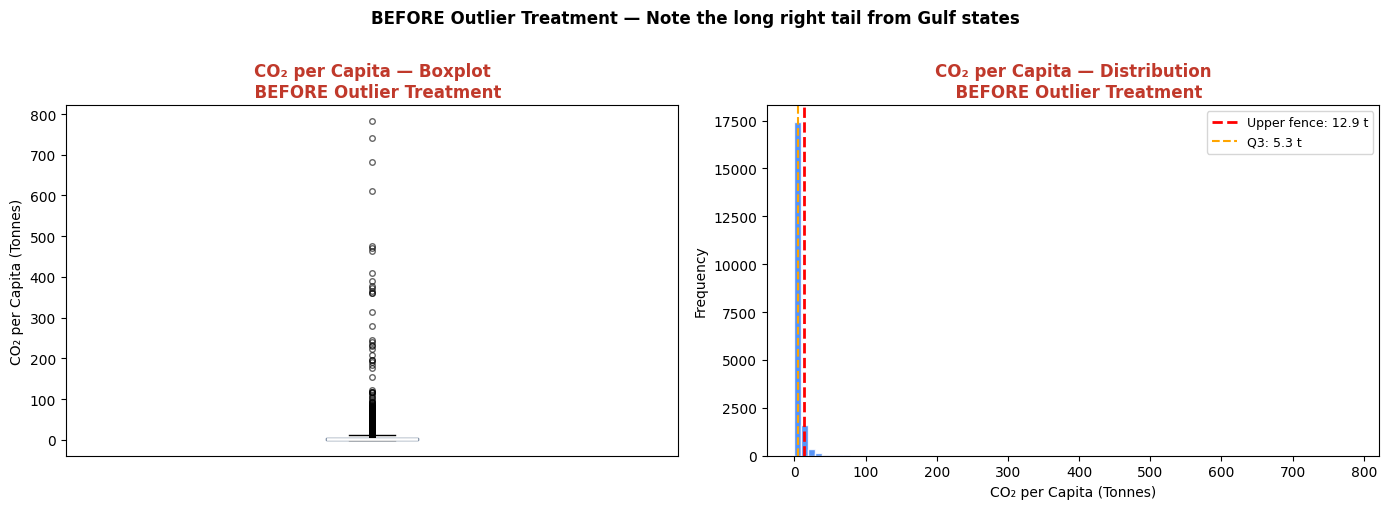

IQR Statistics:
  Q1            = 0.30 tonnes
  Q3            = 5.32 tonnes
  IQR           = 5.02
  Upper Fence   = 12.86 tonnes  (Q3 + 1.5 × IQR)
  Lower Fence   = -7.24 tonnes  (Q1 - 1.5 × IQR)

   Outliers above upper fence: 1300 rows


In [ ]:
# Identifying Outliers

# The BOXPLOT clearly shows the IQR fence and highlights individual
# outlier points as dots beyond the whiskers.
# The HISTOGRAM shows the shape of the distribution - confirming
# whether extreme values are pulling the tail out.
# Using both gives a complete picture before we decide what to do.

# - Total co2 outliers (China, USA) are legitimate large emitters.
#   Removing them would DELETE real, meaningful data about the world's
#   biggest emitters — that would harm our analysis, not help it.
# - co2_per_capita outliers (Gulf states: Qatar ~50t, Kuwait ~30t)
#   are extreme values that skew per-person comparisons across 195 nations.
#   Capping these is appropriate so we can compare countries fairly.

data_pc = df_modern['co2_per_capita'].dropna()

# IQR calculation
Q1  = data_pc.quantile(0.25)
Q3  = data_pc.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(data_pc, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3b82f6', color='#1e3a5f'),
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', color='#ef4444', markersize=4, alpha=0.6))
axes[0].set_title('CO₂ per Capita — Boxplot\n  BEFORE Outlier Treatment', fontweight='bold', color='#c0392b')
axes[0].set_ylabel('CO₂ per Capita (Tonnes)')
axes[0].set_xticks([])

# Histogram
axes[1].hist(data_pc, bins=80, color='#3b82f6', edgecolor='white', alpha=0.85)
axes[1].axvline(upper_fence, color='red',    linestyle='--', linewidth=2, label=f'Upper fence: {upper_fence:.1f} t')
axes[1].axvline(Q3,          color='orange', linestyle='--', linewidth=1.5, label=f'Q3: {Q3:.1f} t')
axes[1].set_title('CO₂ per Capita — Distribution\n  BEFORE Outlier Treatment', fontweight='bold', color='#c0392b')
axes[1].set_xlabel('CO₂ per Capita (Tonnes)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.suptitle('BEFORE Outlier Treatment — Note the long right tail from Gulf states',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

outlier_count = (data_pc > upper_fence).sum()
print(f'IQR Statistics:')
print(f'  Q1            = {Q1:.2f} tonnes')
print(f'  Q3            = {Q3:.2f} tonnes')
print(f'  IQR           = {IQR:.2f}')
print(f'  Upper Fence   = {upper_fence:.2f} tonnes  (Q3 + 1.5 × IQR)')
print(f'  Lower Fence   = {lower_fence:.2f} tonnes  (Q1 - 1.5 × IQR)')
print(f'\n   Outliers above upper fence: {outlier_count} rows')

In [ ]:
# Treat Outliers through dropping or Capping

# Dropping outlier rows would REMOVE entire country-year records.
# For example, Qatar 1980 has a very high per-capita value - but that
# row is REAL and contains valid data for other columns (total co2, gdp etc.)
# Deleting it would LOSE that information entirely.

# Capping means setting a maximum limit on extreme values -
# instead of deleting them, you replace them with the boundary value.
# CAPPING (Winsorization) sets values ABOVE the upper fence to exactly
# the upper fence value(here it is ~12.9). This approach:
#    Preserves the ROW — the country still exists in our data
#    Reduces statistical distortion caused by extreme values
#    Keeps the relative ordering of countries intact
#    Is the standard industry technique for right-skewed continuous
#    data where extreme values carry real meaning but distort statistics

# NOTE: We only cap the UPPER fence.
# No values fall below the lower fence (co2_per_capita cannot be negative).


# Show exactly which country-year rows are being capped (for full transparency)
outlier_rows = df_modern[df_modern['co2_per_capita'] > upper_fence][['country','year','co2_per_capita']]
print(f'Rows being capped (co2_per_capita > {upper_fence:.2f} t):')
print(outlier_rows.sort_values('co2_per_capita', ascending=False).head(15).to_string(index=False))
print(f'\nTotal rows capped : {len(outlier_rows)}')
print(f'Capped to value   : {upper_fence:.2f} tonnes per capita')

# Apply Winsorization — cap upper outliers to the upper fence
df_modern['co2_per_capita'] = np.where(df_modern['co2_per_capita'] > upper_fence, upper_fence, df_modern['co2_per_capita'])

print('\n Outliers are recovered using Capping.')

Rows being capped (co2_per_capita > 12.86 t):
                  country  year  co2_per_capita
Sint Maarten (Dutch part)  1954         782.743
Sint Maarten (Dutch part)  1956         741.272
Sint Maarten (Dutch part)  1951         682.203
Sint Maarten (Dutch part)  1955         610.668
Sint Maarten (Dutch part)  1957         475.291
Sint Maarten (Dutch part)  1959         471.248
Sint Maarten (Dutch part)  1950         463.708
Sint Maarten (Dutch part)  1953         408.740
Sint Maarten (Dutch part)  1958         390.174
Sint Maarten (Dutch part)  1960         376.498
Sint Maarten (Dutch part)  1952         371.757
                   Kuwait  1991         364.791
Sint Maarten (Dutch part)  1962         359.877
Sint Maarten (Dutch part)  1961         359.691
Sint Maarten (Dutch part)  1963         313.931

Total rows capped : 1300
Capped to value   : 12.86 tonnes per capita

 Outliers are recovered using Capping.


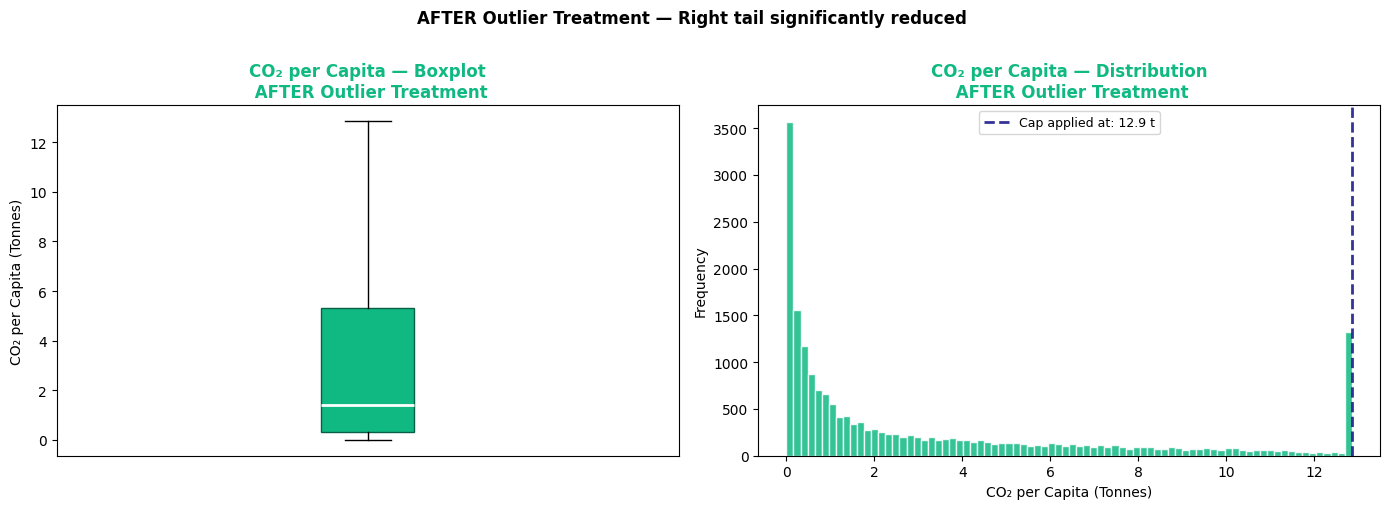

Post-Treatment Verification:
  New Q3            = 5.32 t
  New IQR           = 5.02
  New upper fence   = 12.86 t
  Remaining outliers above new fence: 0

Outlier treatment successful — no extreme values remain above the fence.


In [ ]:
# Re-Check AFTER Outlier Treatment

#   1. Proves the outliers are gone (no red dots above the whisker)
#   2. Shows the distribution is cleaner and less extreme

data_pc_clean = df_modern['co2_per_capita'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Re-Check
axes[0].boxplot(data_pc_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#10b981', color='#065f46'),
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', color='#f97316', markersize=4, alpha=0.5))
axes[0].set_title('CO₂ per Capita — Boxplot\n AFTER Outlier Treatment', fontweight='bold', color='#10b981')
axes[0].set_ylabel('CO₂ per Capita (Tonnes)')
axes[0].set_xticks([])

# Histogram Re-Check
axes[1].hist(data_pc_clean, bins=80, color='#10b981', edgecolor='white', alpha=0.85)
axes[1].axvline(upper_fence, color='navy', linestyle='--', linewidth=2,
                label=f'Cap applied at: {upper_fence:.1f} t', alpha=0.8)
axes[1].set_title('CO₂ per Capita — Distribution\n AFTER Outlier Treatment', fontweight='bold', color='#10b981')
axes[1].set_xlabel('CO₂ per Capita (Tonnes)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.suptitle('AFTER Outlier Treatment — Right tail significantly reduced ',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Verify no remaining outliers above new fence
Q1n  = data_pc_clean.quantile(0.25)
Q3n  = data_pc_clean.quantile(0.75)
IQRn = Q3n - Q1n
new_upper = Q3n + 1.5 * IQRn
remaining = (data_pc_clean > new_upper).sum()

print('Post-Treatment Verification:')
print(f'  New Q3            = {Q3n:.2f} t')
print(f'  New IQR           = {IQRn:.2f}')
print(f'  New upper fence   = {new_upper:.2f} t')
print(f'  Remaining outliers above new fence: {remaining}')
print()

print('Outlier treatment successful — no extreme values remain above the fence.')

Skewness BEFORE transformation:
  co2                      :   13.515  → Highly skewed — log transform needed
  co2_per_capita           :    1.217  → Highly skewed — log transform needed
  population               :   10.076  → Highly skewed — log transform needed
  gdp                      :   12.697  → Highly skewed — log transform needed

Skewness AFTER log1p transformation:
  log_co2                  : 0.876  → More symmetric


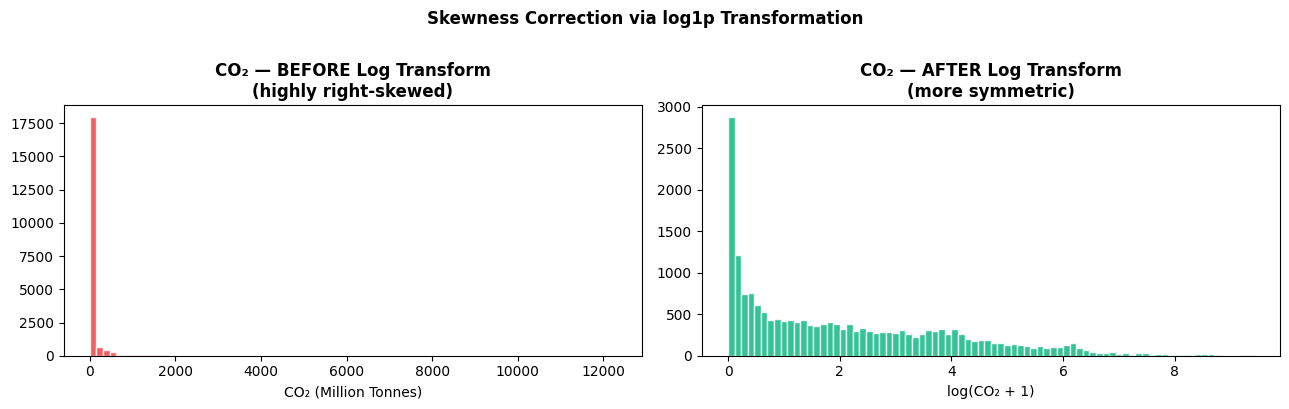


 Derived columns added: gdp_per_capita, log_co2
Final clean dataset shape: (19787, 81)


In [ ]:
# Check Skewness

# Skewness measures the asymmetry of a distribution.
#   > +1.0  -> Highly right-skewed (long tail to the right)
#   < -1.0  -> Highly left-skewed (long tail to the left)
#   ±0–1.0  -> Approximately symmetric (acceptable for most analyses)
# Highly skewed data violates normality assumptions used in statistical
# tests and makes visualizations harder to interpret (most values bunched
# near zero, a few extreme values stretching the axis).

# For right-skewed data (like CO2 totals and GDP), applying log1p —
# which computes log(x + 1) - compresses the long right tail and brings
# the distribution closer to symmetric/normal.
# We use log1p (not log) because:
#   log(0) = undefined (causes errors for countries with zero emissions)
#   log1p(0) = 0 (safely handles zero values)

skew_cols = ['co2', 'co2_per_capita', 'population', 'gdp']
print('Skewness BEFORE transformation:')
for col in skew_cols:
    sk = df_modern[col].skew()
    flag = '→ Highly skewed — log transform needed' if abs(sk) > 1 else '→ Acceptable'
    print(f'  {col:25s}: {sk:8.3f}  {flag}')

# Apply log1p to highly skewed columns
# WHY gdp_per_capita derived here: GDP per capita tells us economic output
# per person — essential for fair cross-country comparison (a country's
# raw GDP is heavily influenced by population size, which is misleading).
df_modern['gdp_per_capita'] = df_modern['gdp'] / df_modern['population']
df_modern['log_co2']        = np.log1p(df_modern['co2'])

print('\nSkewness AFTER log1p transformation:')
print(f'  {"log_co2":25s}: {df_modern["log_co2"].skew():.3f}  → More symmetric')

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_modern['co2'].dropna(), bins=80, color='#ef4444', edgecolor='white', alpha=0.85)
axes[0].set_title('CO₂ — BEFORE Log Transform\n(highly right-skewed)', fontweight='bold')
axes[0].set_xlabel('CO₂ (Million Tonnes)')

axes[1].hist(df_modern['log_co2'].dropna(), bins=80, color='#10b981', edgecolor='white', alpha=0.85)
axes[1].set_title('CO₂ — AFTER Log Transform\n(more symmetric)', fontweight='bold')
axes[1].set_xlabel('log(CO₂ + 1)')

plt.suptitle('Skewness Correction via log1p Transformation', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\n Derived columns added: gdp_per_capita, log_co2')
print(f'Final clean dataset shape: {df_modern.shape}')

In [ ]:
# Saving the cleaned dataset as a CSV means Stage 3 (EDA) can load the
# CLEAN version directly without re-running all cleaning steps each time.
# It also allows the dataset to be uploaded to Google Drive and shared
# as evidence of the cleaning process for the project submission.

df_modern.to_csv('cleaned_co2_dataset.csv', index=False)
# df_modern.to_excel('cleaned_co2_dataset.xlsx', index=False)  # Uncomment for Excel

print('Cleaned dataset saved as cleaned_CO2_dataset.csv')
print()
print('=== STAGE 2 COMPLETE — CLEANING SUMMARY ===')
print(f'  Final shape            : {df_modern.shape[0]:,} rows × {df_modern.shape[1]} columns')
print(f'  Year range             : {df_modern["year"].min()} – {df_modern["year"].max()}')
print(f'  Unique countries       : {df_modern["country"].nunique()}')
print(f'  Imputation A (sources) : Filled with 0 — no fuel use = 0 emissions')
print(f'  Imputation B (gdp)     : Filled with per-country MEDIAN — skew-resistant')
print(f'  Imputation C (per cap) : Filled with per-country MEDIAN — skew-resistant')
print(f'  Imputation D (co2)     : Dropped null rows — cannot fabricate core target')
print(f'  Duplicates             : None found')
print(f'  Outliers               : Capped co2_per_capita via Winsorization (IQR method)')
print(f'  Skewness               : log1p applied to co2 column')
print(f'  Derived features       : gdp_per_capita, log_co2')


Cleaned dataset saved as cleaned_CO2_dataset.csv

=== STAGE 2 COMPLETE — CLEANING SUMMARY ===
  Final shape            : 19,787 rows × 81 columns
  Year range             : 1900 – 2024
  Unique countries       : 215
  Imputation A (sources) : Filled with 0 — no fuel use = 0 emissions
  Imputation B (gdp)     : Filled with per-country MEDIAN — skew-resistant
  Imputation C (per cap) : Filled with per-country MEDIAN — skew-resistant
  Imputation D (co2)     : Dropped null rows — cannot fabricate core target
  Duplicates             : None found
  Outliers               : Capped co2_per_capita via Winsorization (IQR method)
  Skewness               : log1p applied to co2 column
  Derived features       : gdp_per_capita, log_co2


## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables

Bivariate Analysis → relation between two variables

Multivariate Analysis → relation among 3+ variables

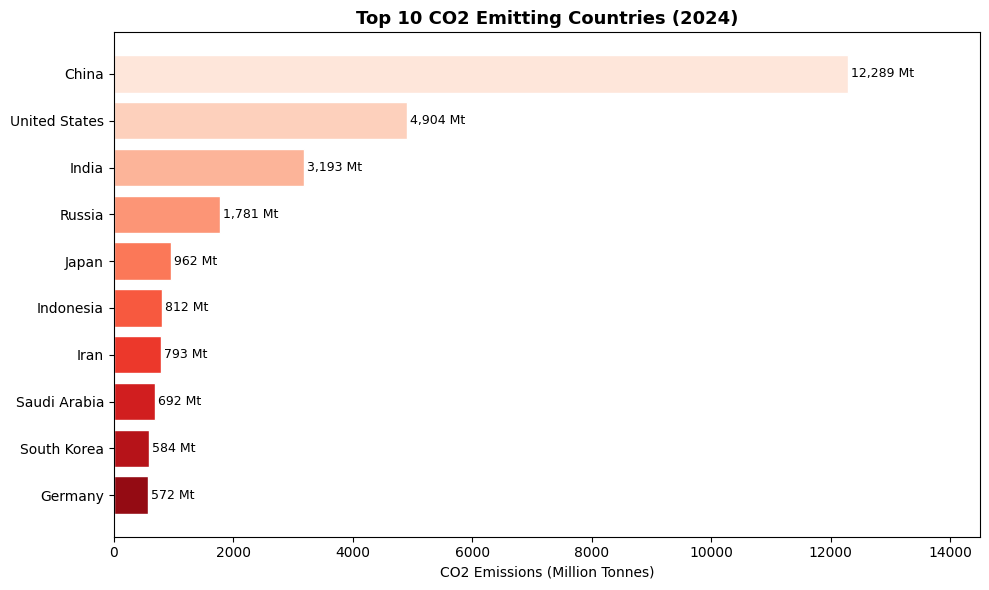

In [ ]:
# Horizontal bar chart: Top 10 CO2 Emitting Countries
latest_year = df_modern['year'].max()
latest = df_modern[df_modern['year'] == latest_year].dropna(subset=['co2'])
top10 = latest.nlargest(10, 'co2')[['country', 'co2']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Reds_r', 10)
bars = ax.barh(top10['country'][::-1], top10['co2'][::-1], color=colors, edgecolor='white')

for bar, val in zip(bars, top10['co2'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} Mt', va='center', fontsize=9)

ax.set_title(f'Top 10 CO2 Emitting Countries ({latest_year})', fontsize=13, fontweight='bold')
ax.set_xlabel('CO2 Emissions (Million Tonnes)')
ax.set_xlim(0, top10['co2'].max() * 1.18)
plt.tight_layout()
plt.show()

## Top 10 CO2 Emitting Countries

- Its a Horizontal Bar Chart (Univariate)
- Features used are country, co2 (latest year)
- It shows that China dominates global CO2 output, followed by the United States and India. Together, the top 3 nations account for more than half of global emissions.
- From this we understand thet a small number of countries are responsible for a disproportionately large share of global emissions. Any meaningful global climate strategy must prioritize these top emitters.

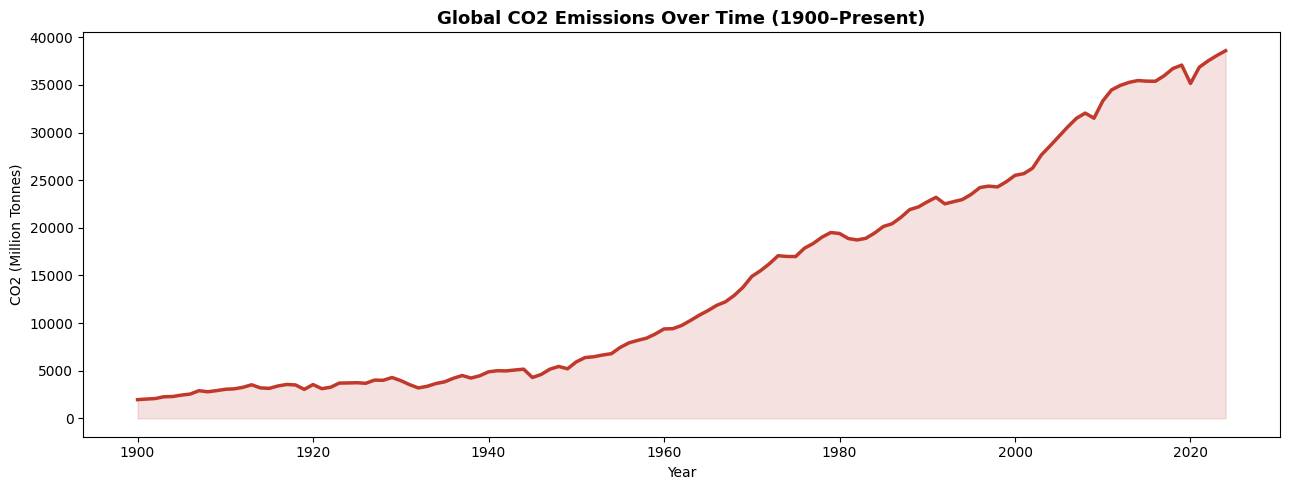

In [ ]:
# Global CO2 emissions trend over time
world = df_world_m.dropna(subset=['co2'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(world['year'], world['co2'], color='#c0392b', linewidth=2.5, zorder=3)
ax.fill_between(world['year'], world['co2'], alpha=0.15, color='#c0392b')

ax.set_title('Global CO2 Emissions Over Time (1900–Present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CO2 (Million Tonnes)')
plt.tight_layout()
plt.show()

## Global CO2 emissions trend over time

- Its a Line Chart with Area Fill (Bivariate)
- Features used here are year, co2 (World aggregate)
- It shows the global CO2 emissions have grown almost continuously since 1900.
- From this chart we can understand that Human industrial activity drives a relentless upward emissions trend.

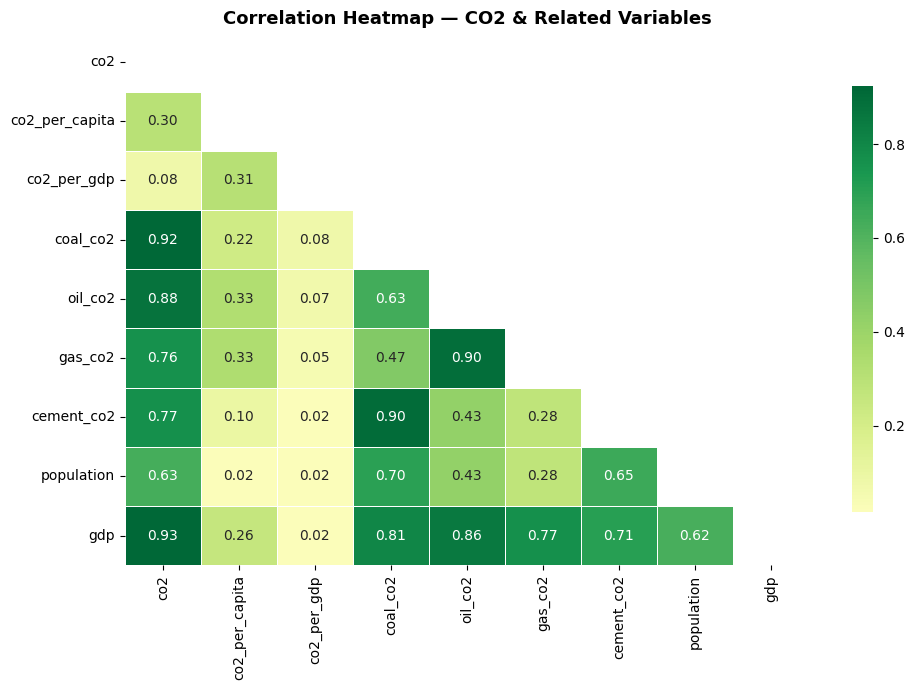

In [ ]:
# Correlation heatmap
corr_cols = ['co2', 'co2_per_capita', 'co2_per_gdp',
             'coal_co2', 'oil_co2', 'gas_co2',
             'cement_co2', 'population', 'gdp']
corr_data = df_modern[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — CO2 & Related Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap — CO2 & Related Variables

- Its a Correlation Heatmap (Bivariate)
- Features used are co2, co2_per_capita, coal_co2, oil_co2, gas_co2, cement_co2, population, gdp
- It shows that the total CO2 has a very strong positive correlation with GDP (0.8+) and population. Coal, oil, and gas individually also correlate strongly with total CO2. co2_per_gdp (emission intensity) correlates negatively with GDP, suggesting richer economies are more emission-efficient.
- From this we can understand that economic size and population are the two biggest predictors of total emissions. However, wealthier countries tend to be more energy-efficient per dollar of GDP, suggesting technological advancement helps decouple growth from pollution.

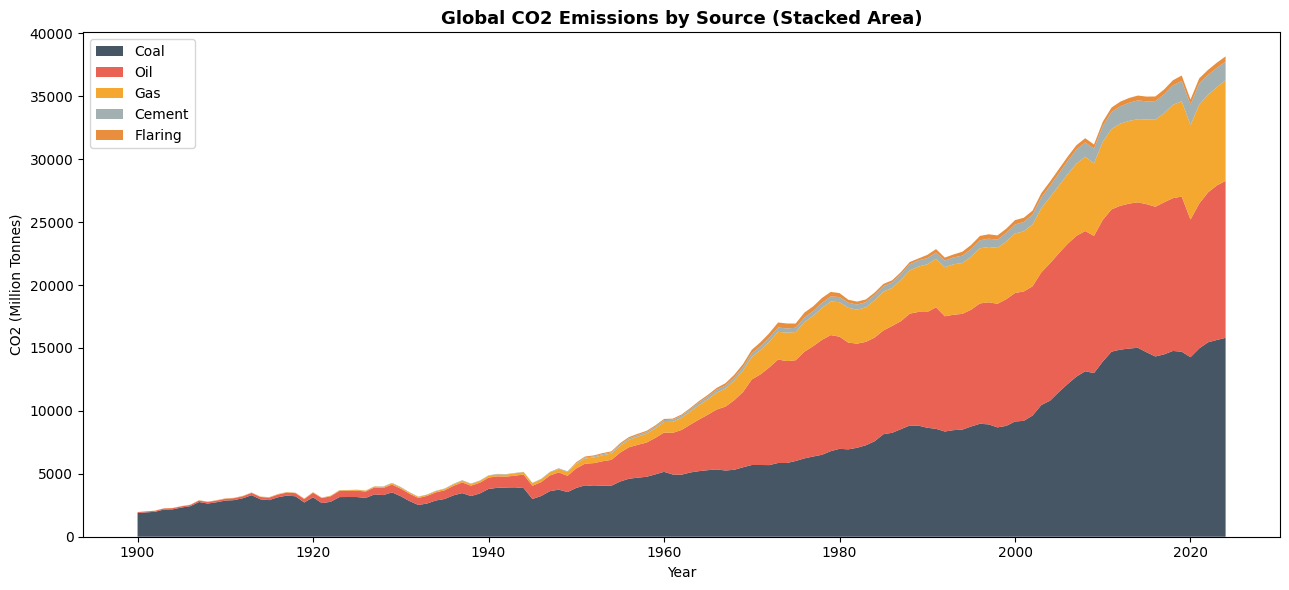

In [ ]:
# Stacked area chart: CO2 by source over time
sources    = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2']
src_labels = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring']
src_colors = ['#2c3e50', '#e74c3c', '#f39c12', '#95a5a6', '#e67e22']

src_data = df_world_m[['year'] + sources].dropna()

fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(src_data['year'],
             [src_data[s] for s in sources],
             labels=src_labels, colors=src_colors, alpha=0.88)
ax.set_title('Global CO2 Emissions by Source (Stacked Area)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CO2 (Million Tonnes)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## Global CO2 Emissions by Source (Stacked Area)

- Its a Stacked Area Chart (Multivariate)
- Features used here are year, coal_co2, oil_co2, gas_co2, cement_co2, flaring_co2
- It shows that coal dominated emissions throughout most of industrial history. Oil grew rapidly from the 1950s. Gas has grown steadily since the 1970s. Cement has increased sharply since 2000.
- From this we can understand that the energy transition story is visible here - coal still leads, but oil and gas combined now rival coal. Tackling coal (the dirtiest fuel) would deliver the single biggest emissions reduction. Cement's rise signals the infrastructure demands of developing economies.

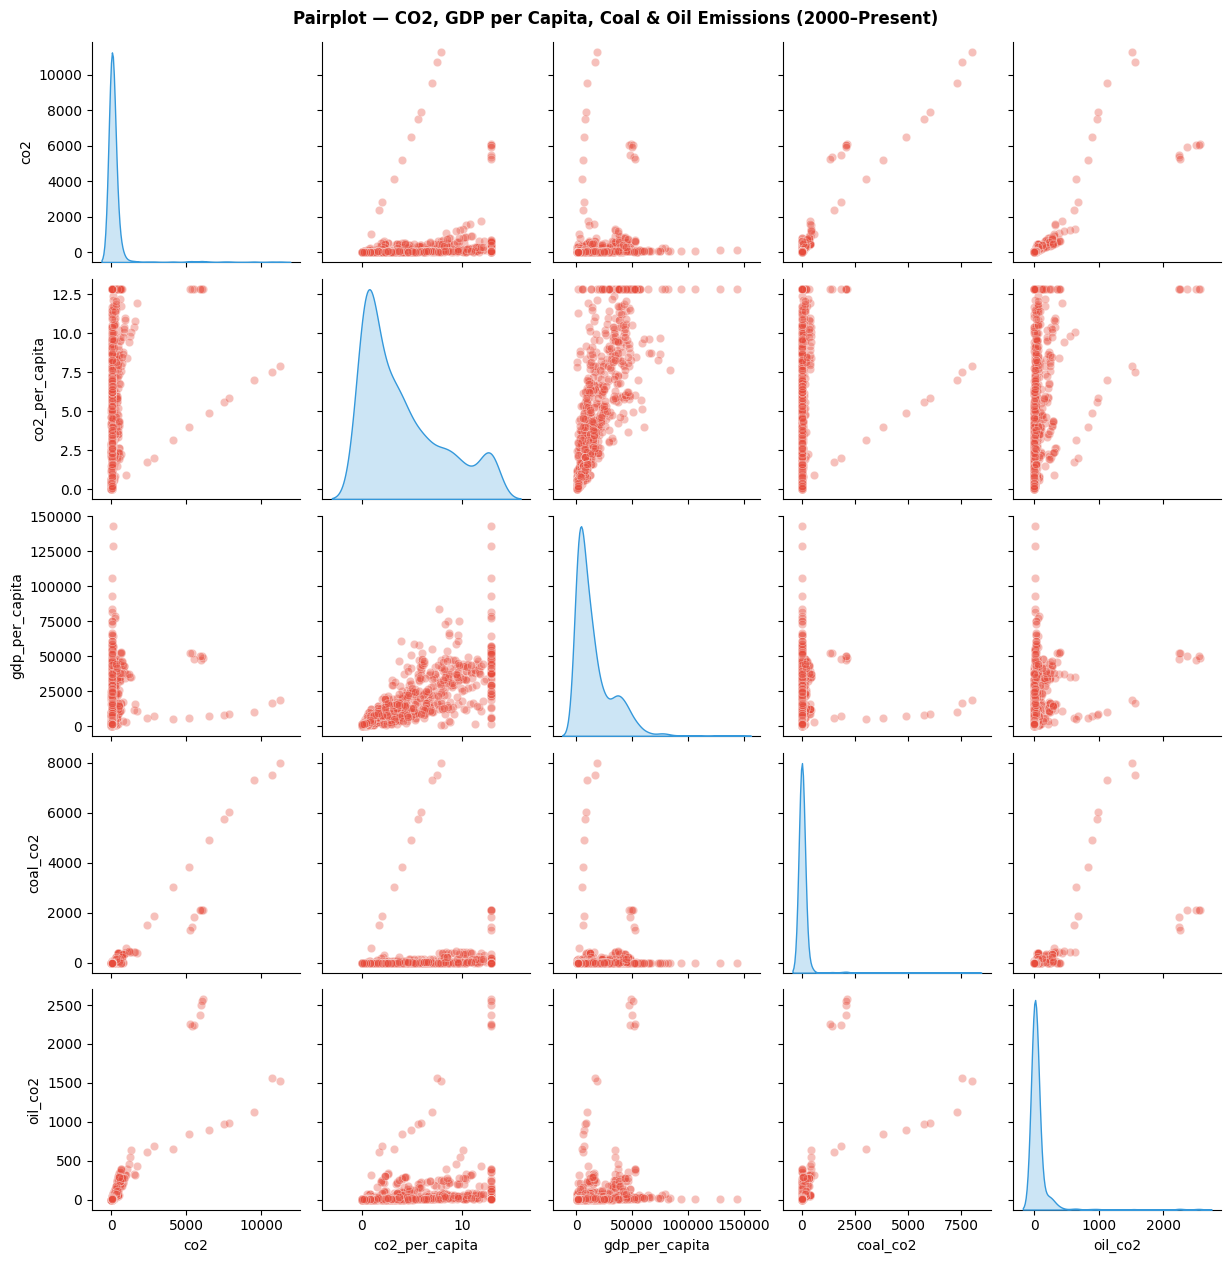

In [ ]:
# Pairplot of key variables
pair_cols = ['co2', 'co2_per_capita', 'gdp_per_capita', 'coal_co2', 'oil_co2']
pair_data = df_modern[(df_modern['year'] >= 2000)][pair_cols].dropna()
pair_sample = pair_data.sample(min(1000, len(pair_data)), random_state=42)

g = sns.pairplot(pair_sample, diag_kind='kde', plot_kws={'alpha': 0.35, 'color': '#e74c3c'},
                 diag_kws={'color': '#3498db'})
g.fig.suptitle('Pairplot — CO2, GDP per Capita, Coal & Oil Emissions (2000–Present)',
               y=1.01, fontsize=12, fontweight='bold')
plt.show()

## Pairplot — CO2, GDP per Capita, Coal & Oil Emissions (2000–Present)

- Its a Pairplot (Multivariate)
- Features used are co2, co2_per_capita, gdp_per_capita, coal_co2, oil_co2
- It shows a strong positive linear relationships exist between total CO2, coal CO2, and oil CO2 - confirming fossil fuels dominate. GDP per capita shows a moderate positive relationship with co2_per_capita, with scatter indicating some countries break the trend.
- From this we can understand that the clustering of data points in the pairplot reveals that coal and oil emissions move together - countries that burn more coal also tend to burn more oil. Countries deviating from the GDP-emissions trend represent potential 'green economy' success stories.

## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


In [ ]:
# https://drive.google.com/file/d/11pa59UVI6ct0eRu2mnqiTVBi-AijtZO9/view?usp=sharing